204
2.162324649298597
-0.041435092
-0.037324079


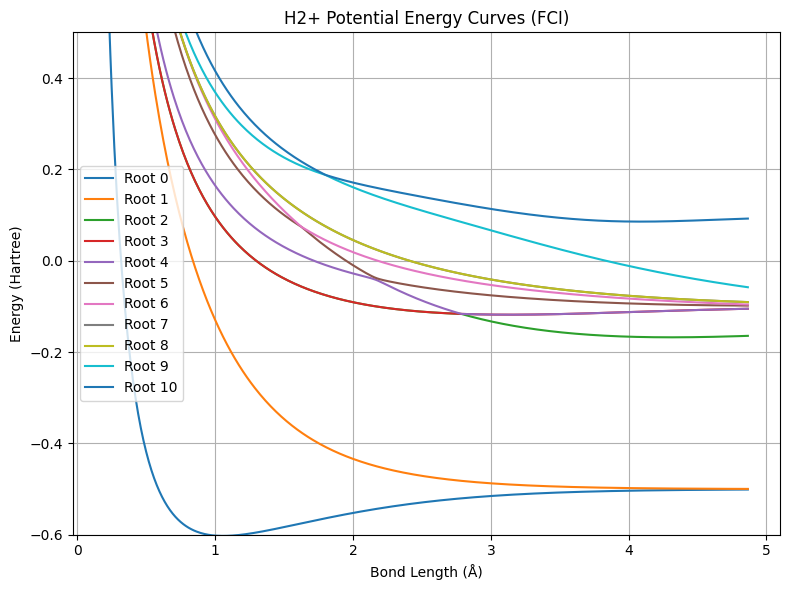

In [313]:
import csv
import numpy as np
import matplotlib.pyplot as plt

filename = "h2plus_fci_pec copy 2.csv"

R = []

with open(filename, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    n_roots = len(header) - 1
    energies = [[] for _ in range(n_roots)]
    
    for row in reader:
        R.append(float(row[0]))

        for i in range(n_roots):
            try:
                val = float(row[i+1])
            except:
                val = np.nan
            energies[i].append(val)

def min_dist(R, E1, E2):
    R = np.array(R)
    E1 = np.array(E1) 
    E2 = np.array(E2)

    Ediff = E1 - E2
    #print(Ediff)

    #############################
    max_diff = abs(Ediff[1] - Ediff[0])
    max_index = 0

    for i in range(len(Ediff) - 1):
        diff = abs(Ediff[i+1] - Ediff[i])
        if diff > max_diff:
            max_diff = diff
            max_index = i

    #print(max_index-1)
    #print(Ediff[max_index-1])
          
    min_idx = np.abs(Ediff).argmin()

    return min_idx, R[min_idx], E1[min_idx], E2[min_idx]

min_idx, Rcross, E1cross, E2cross = min_dist(R, energies[4], energies[5]) 

print(min_idx)
print(Rcross)
print(E1cross)
print(E2cross)

plt.figure(figsize=(8,6))
for i, e in enumerate(energies):
    plt.plot(R, e, label=f"Root {i}")

#plt.plot(R[204],energies[4][204], "o")

plt.ylim(-0.6, 0.5)
#plt.xlim(0, 3)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("H2+ Potential Energy Curves (FCI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

500


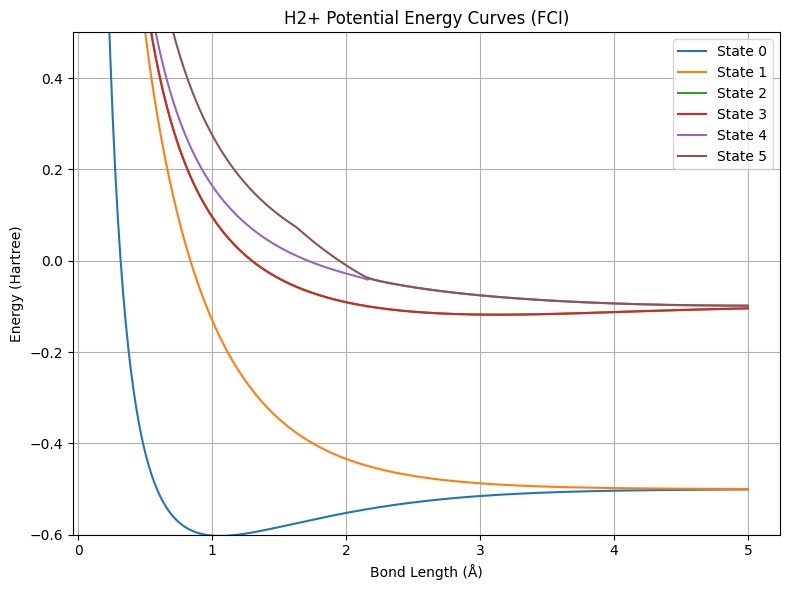

In [295]:
import csv
import numpy as np
import matplotlib.pyplot as plt

filename = "h2plus_fci_pec.csv"

R = []

with open(filename, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    n_roots = len(header) - 1
    energies = [[] for _ in range(n_roots)]
    
    for row in reader:
        R.append(float(row[0]))

        for i in range(n_roots):
            try:
                val = float(row[i+1])
            except:
                val = np.nan
            energies[i].append(val)

excited_states = []

for i in range (0,len(energies)):
    excited_states.append(energies[i])

excited_states[2] = energies[2][0:270] + energies[4][270:500]
excited_states[4] = energies[4][0:205] + energies[5][205:500]

print(len(excited_states[4]))


plt.figure(figsize=(8,6))
#for i, e in enumerate(energies):
#    plt.plot(R, e, label=f"Root {i}")

for i in range (0, 6):#len(excited_states)):
    plt.plot(R, excited_states[i], label=f"State {i}")

#plt.plot(Rsmall, excited_states[2], label =f"State 2")

#plt.plot(R[269],energies[2][269], "o")
plt.ylim(-0.6, 0.5)
#plt.xlim(0, 3)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("H2+ Potential Energy Curves (FCI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

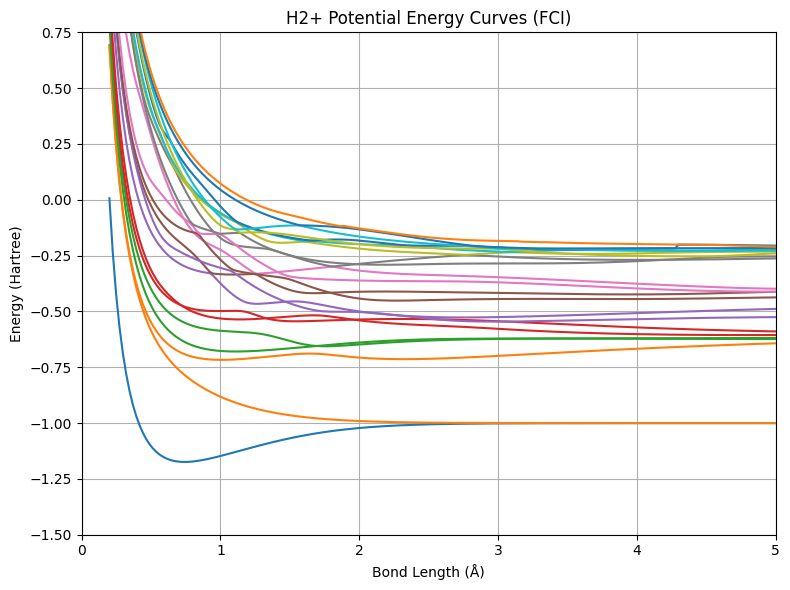

In [336]:
import csv
import numpy as np
import matplotlib.pyplot as plt

filename = "h2_fci_singlet_triplet.csv"

R = []

with open(filename, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    n_roots = len(header) - 1
    energies = [[] for _ in range(n_roots)]
    
    for row in reader:
        R.append(float(row[0]))

        for i in range(n_roots):
            try:
                val = float(row[i+1])
            except:
                val = np.nan
            energies[i].append(val)

plt.figure(figsize=(8,6))
for i, e in enumerate(energies):
    plt.plot(R, e, label=f"Root {i}")

#plt.plot(R[204],energies[4][204], "o")

plt.ylim(-1.5, 0.75)
plt.xlim(0, 5)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("H2+ Potential Energy Curves (FCI)")
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()